## Importación de Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_gaussian_quantiles

## Generación de un Dataset de Clasificación con make_gaussian_quantiles

In [ ]:
N=1000

gaussian_quantiles = make_gaussian_quantiles(mean=None, 
                                            cov=1.0,
                                            n_samples=N, 
                                            n_features=2, 
                                            n_classes=2,
                                            shuffle=True,
                                            random_state=None)

In [ ]:
X, y = gaussian_quantiles

In [ ]:
X.shape

(1000, 2)

In [ ]:
y.shape

(1000,)

In [ ]:
y=y.reshape(-1, 1)
y.shape

(1000, 1)

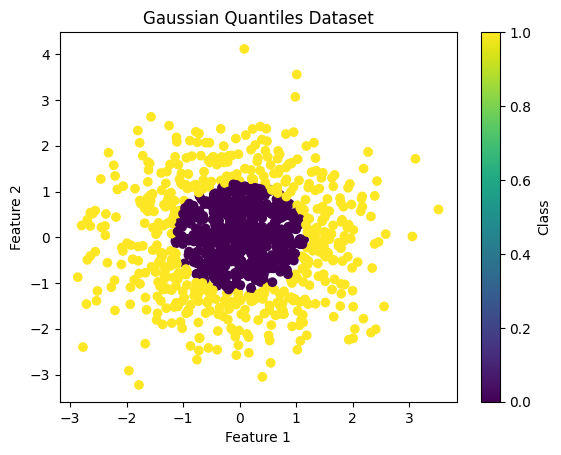

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Gaussian Quantiles Dataset')
plt.colorbar(label='Class')
plt.show()

## Funciones de Activación

### Función Sigmoide

In [ ]:
def sigmoid(x, deriv=False): 
		if deriv: 
				return np.exp(-x) / ((1 + np.exp(-x)) ** 2) 
		else:
				return 1 / (1 + np.exp(-x))

### Función ReLu

In [19]:
def relu(x, deriv=False): 
		if deriv: 
				return np.where(x <= 0, 0, 1) 
		else:
				return np.maximum(0, x)

## Funcion de Pérdida

In [ ]:
def MSE(Y, Y_hat, derivate=False): 
    if derivate: 
        return 2 * (Y_hat - Y)
    else:
        return np.mean((Y_hat - Y) ** 2)

### Inicialización de W y b para una Red Neuronal Profunda

In [ ]:
def initialize_parameters_deep(layer_dims): 
		parameters = {} 
		L = len(layer_dims) 
		for l in range(0, L - 1): 
				parameters['W' + str(l + 1)] = np.random.rand(layer_dims[l], layer_dims[l + 1]) * 2 - 1 
				parameters['b' + str(l + 1)] = np.random.rand(1, layer_dims[l + 1]) * 2 - 1 
		return parameters

In [ ]:
layer_dims = [2, 4, 8, 1]
parameters = initialize_parameters_deep(layer_dims)
parameters

{'W1': array([[ 0.4822793 ,  0.3824933 , -0.87291035,  0.75884781],
        [-0.49675347,  0.25833846, -0.00725638,  0.18876144]]),
 'b1': array([[ 0.37128505, -0.11532388, -0.46424466, -0.30557781]]),
 'W2': array([[ 0.14268633, -0.86379341,  0.89910422,  0.63595837, -0.93909332,
         -0.37041808,  0.08351375,  0.95434955],
        [ 0.15938714,  0.98210029,  0.88576345, -0.63666321,  0.00478508,
         -0.95232518,  0.38643641,  0.27266654],
        [-0.58140812, -0.19793844, -0.46143061,  0.41008845,  0.45508863,
          0.11580841,  0.86123326,  0.84253213],
        [-0.74467426,  0.32093785, -0.63583459,  0.73268705,  0.29571067,
         -0.48036354,  0.95094425, -0.77308804]]),
 'b2': array([[-0.12337219, -0.13330162, -0.7932726 , -0.49999496,  0.00646605,
         -0.0300649 ,  0.0975922 ,  0.87221806]]),
 'W3': array([[-0.00288459],
        [ 0.98461164],
        [-0.5411284 ],
        [-0.56605906],
        [-0.25838549],
        [-0.31537115],
        [-0.17567339],


In [ ]:
parameters['W1'].shape

(2, 4)

## Entrenamiento de Propagación Directa (Foward Propagation)

In [14]:
def train(X, y, parameters, lr, training=True):

    #Forward Propagation
    parameters['A0'] = X

    parameters['Z1'] = np.dot(parameters['A0'], parameters['W1']) + parameters['b1']
    parameters['A1'] = relu(parameters['Z1'])

    parameters['Z2'] = np.dot(parameters['A1'], parameters['W2']) + parameters['b2']
    parameters['A2'] = relu(parameters['Z2'])

    parameters['Z3'] = np.dot(parameters['A2'], parameters['W3']) + parameters['b3']
    parameters['A3'] = sigmoid(parameters['Z3'])

    output=parameters['A3']

    if training:

    #Backpropagation
    
        m = X.shape[0]
        parameters['dZ3'] = MSE(y, output, derivate=True) * sigmoid(parameters['Z3'], deriv=True)
        parameters['dW3'] = np.dot(parameters['A2'].T, parameters['dZ3'])/m

        parameters['dZ2'] = np.dot(parameters['dZ3'], parameters['W3'].T) * relu(parameters['Z2'], deriv=True)
        parameters['dW2'] = np.dot(parameters['A1'].T, parameters['dZ2'])/m

        parameters['dZ1'] = np.dot(parameters['dZ2'], parameters['W2'].T) * relu(parameters['Z1'], deriv=True)
        parameters['dW1'] = np.dot(parameters['A0'].T, parameters['dZ1'])/m
        


        # Gradient Descent

        parameters['W3']=parameters['W3'] - (lr * parameters['dW3'])
        parameters['b3']=parameters['b3'] - (lr * np.mean(parameters['dZ3'], axis=0, keepdims=True))

        parameters['W2']=parameters['W2'] - (lr * parameters['dW2'])
        parameters['b2']=parameters['b2'] - (lr * np.mean(parameters['dZ2'], axis=0, keepdims=True))

        parameters['W1']=parameters['W1'] - (lr * parameters['dW1'])
        parameters['b1']=parameters['b1'] - (lr * np.mean(parameters['dZ1'], axis=0, keepdims=True))
    
    return output


Iteración 0 | Error: 0.2999
Iteración 1000 | Error: 0.2139
Iteración 2000 | Error: 0.1839
Iteración 3000 | Error: 0.1568
Iteración 4000 | Error: 0.1269
Iteración 5000 | Error: 0.0995
Iteración 6000 | Error: 0.0811
Iteración 7000 | Error: 0.0685
Iteración 8000 | Error: 0.0590
Iteración 9000 | Error: 0.0516
Iteración 10000 | Error: 0.0461
Iteración 11000 | Error: 0.0418
Iteración 12000 | Error: 0.0385
Iteración 13000 | Error: 0.0358
Iteración 14000 | Error: 0.0336
Iteración 15000 | Error: 0.0318
Iteración 16000 | Error: 0.0303
Iteración 17000 | Error: 0.0290
Iteración 18000 | Error: 0.0278
Iteración 19000 | Error: 0.0268
Iteración 20000 | Error: 0.0258
Iteración 21000 | Error: 0.0250
Iteración 22000 | Error: 0.0241
Iteración 23000 | Error: 0.0234
Iteración 24000 | Error: 0.0227
Iteración 25000 | Error: 0.0221
Iteración 26000 | Error: 0.0215
Iteración 27000 | Error: 0.0210
Iteración 28000 | Error: 0.0205
Iteración 29000 | Error: 0.0201


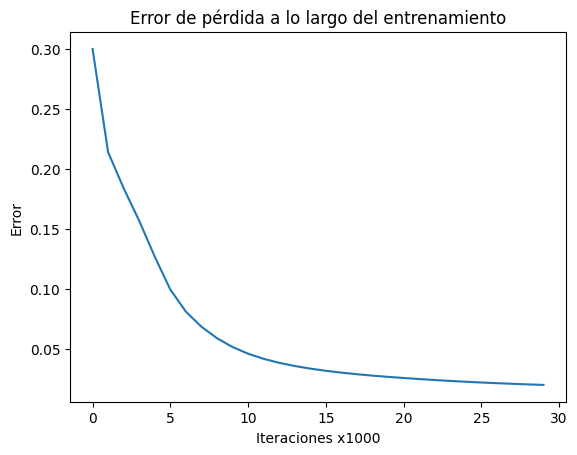

In [15]:
errores = []
for i in range(30000):    
    output = train(X, y, parameters, lr=0.01) 
    
    if i % 1000 == 0: 
        error_actual = MSE(y, output)
        print(f"Iteración {i} | Error: {error_actual:.4f}")        
        errores.append(error_actual)

# Opcional: Graficar el error
plt.plot(errores)
plt.title("Error de pérdida a lo largo del entrenamiento")
plt.xlabel("Iteraciones x1000")
plt.ylabel("Error")
plt.show()

## Creación de Data de Prueba y Evaluación del Modelo

In [16]:
data_test=(np.random.rand(3000, 2) *6)-3
Y_test= train(data_test, None, parameters, lr=0.001, training=False)

Y_test.shape

(3000, 1)

In [17]:
Y_test=np.where(Y_test > 0.5, 1, 0)
Y_test.shape

(3000, 1)

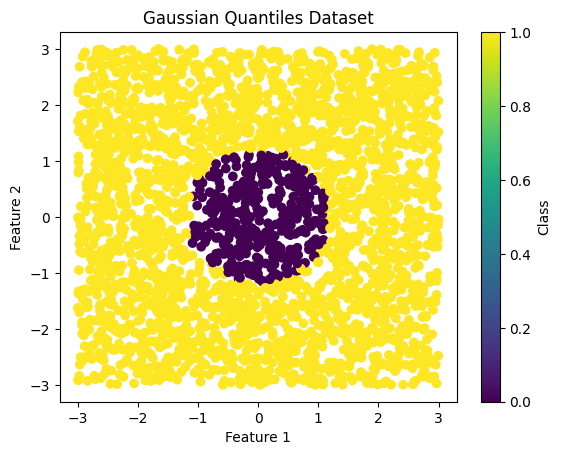

In [18]:
plt.scatter(data_test[:, 0], data_test[:, 1], c=Y_test[:, 0], cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Gaussian Quantiles Dataset')
plt.colorbar(label='Class')
plt.show()